In [1]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../results/suitesparse_normalized_comparison.csv')

# The iters1000 sweep (max_iters=1000 instead of 2000) only exists as unmerged
# per-shard CSVs; concatenate them here and relabel so they don't collide with
# the default 'TorusMDS' rows already in the main comparison file.
iters1000_shards = sorted(glob.glob('../results/suitesparse_normalized_iters1000_shard_*_comparison.csv'))
df_iters1000 = pd.concat([pd.read_csv(f) for f in iters1000_shards], ignore_index=True)
df_iters1000['method'] = 'TorusMDS_iters1000'
df = pd.concat([df, df_iters1000], ignore_index=True)

METHODS = [
    's_gd2', 'wrap_python',
    'TorusMDS', 'TorusMDS_iters1000',
    'TorusMDS_smart_1x', 'TorusMDS_smart_100x',
    'TorusMDS_random_1x', 'TorusMDS_random_100x',
]
COLORS  = {
    's_gd2':                 '#4C72B0',
    'wrap_python':           '#55A868',
    'TorusMDS':              '#DD8452',
    'TorusMDS_iters1000':    '#937860',
    'TorusMDS_smart_1x':     '#C44E52',
    'TorusMDS_smart_100x':   '#8172B2',
    'TorusMDS_random_1x':    '#CCB974',
    'TorusMDS_random_100x':  '#64B5CD',
}
METRICS = ['stress', 'pointwise_stress']
LABELS  = {
    'stress':           'Normalized stress',
    'pointwise_stress': 'Pointwise-normalized stress',
    'distortion':       'Distortion',
    'sgs':              'SGS (Spearman rank corr.)',
    'np_score':         'Neighbourhood preservation',
    't_embed':          'Embedding time (s)',
}

# TorusMDS is the default (fixed-geometry) normalized run; TorusMDS_iters1000
# is the same but capped at max_iters=1000. TorusMDS_{smart,random}_{1x,100x}
# are alpha_aspect runs that jointly learn alpha and the aspect ratio (r0, r1);
# smart/random is the init strategy (spectral vs none), 1x/100x is the
# batch-size multiplier (4096 vs 409600).

data = {m: df[df['method'] == m] for m in METHODS}
print('--- overall ---')
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'std']).round(4))
print('\n--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---')
print(df.groupby('method')['matrix_id'].nunique())
print('\n--- top 10 SuiteSparse groups by graph count ---')
print(df.drop_duplicates('matrix_id')['group'].value_counts().head(10))


--- overall ---
                      stress         pointwise_stress          t_embed  \
                        mean     std             mean     std     mean   
method                                                                   
TorusMDS              0.2629  0.1201           0.4208  0.8932   9.1239   
TorusMDS_iters1000    0.3338  0.1112           0.6962  1.3775   2.3891   
TorusMDS_random_100x  0.1891  0.1210           0.2371  0.1485  99.6324   
TorusMDS_random_1x    0.1913  0.1050           0.2371  0.1013   1.8721   
TorusMDS_smart_100x   0.2057  0.1393           0.2532  0.1626  98.9034   
TorusMDS_smart_1x     0.2201  0.1306           0.2687  0.1213   2.6500   
s_gd2                 0.1647  0.1094           0.2047  0.1032   3.4432   
wrap_python           0.2488  0.1109           0.2523  0.1124  13.4676   

                               
                          std  
method                         
TorusMDS               4.0324  
TorusMDS_iters1000     3.4027  
TorusMDS_

## Violin plots

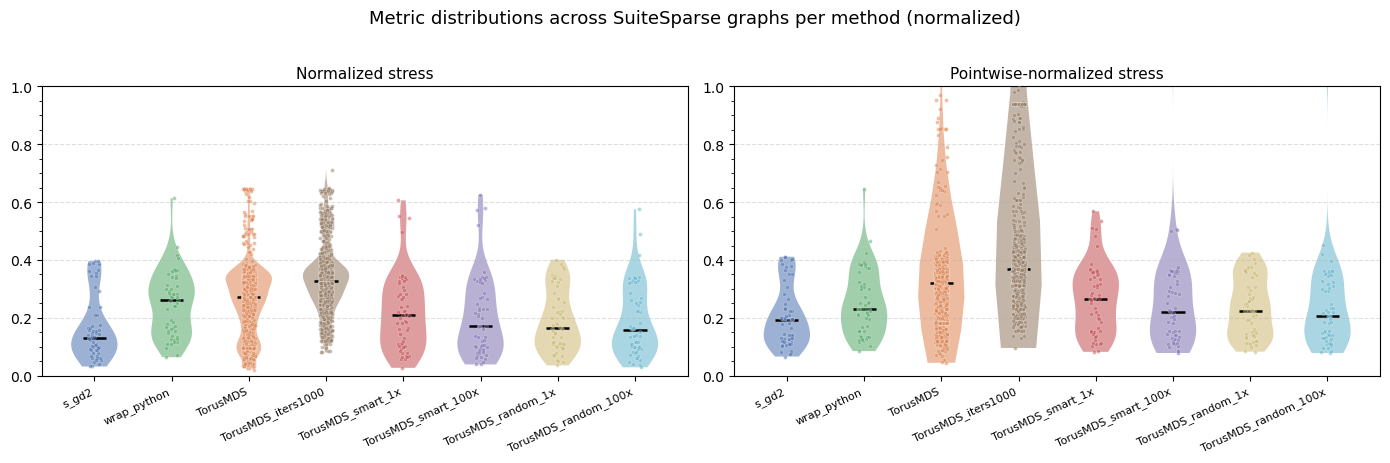

In [4]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].dropna().values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].dropna().values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=8, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.5)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=8, rotation=25, ha='right')
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1)

fig.suptitle('Metric distributions across SuiteSparse graphs per method (normalized)', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs graph size n

Note: `wrap_python` is capped at `--wrap-python-max-n` (graphs above that size were skipped during embedding), so its trend line stops early -- that's expected, not missing data.

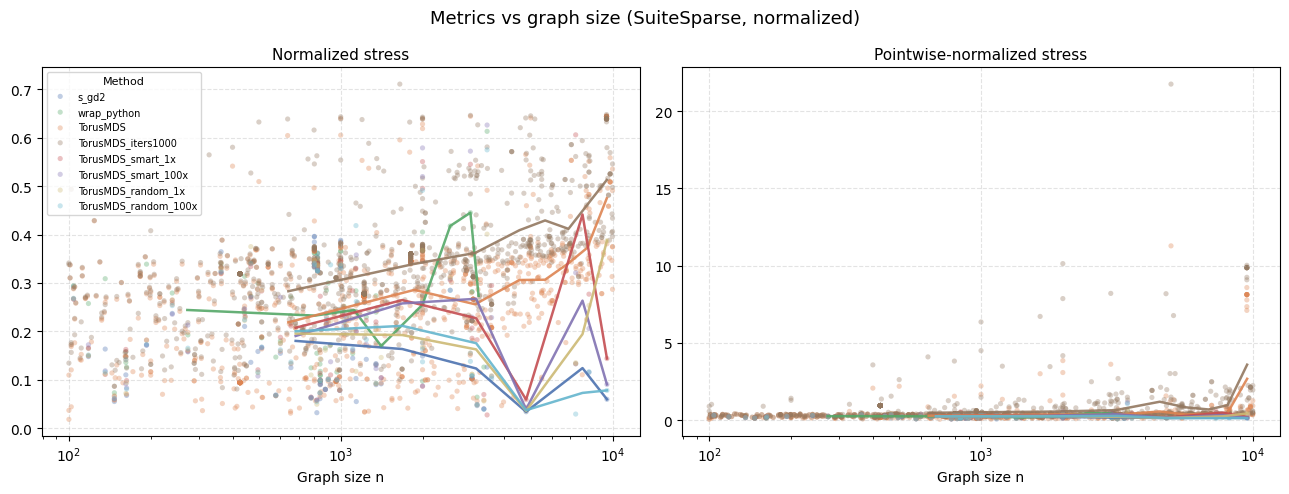

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=14, color=COLORS[m],
                   alpha=0.35, label=m, edgecolors='none')
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_xscale('log')
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes[0].legend(title='Method', fontsize=7, title_fontsize=8)
fig.suptitle('Metrics vs graph size (SuiteSparse, normalized)', fontsize=13)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()

## Running time distributions

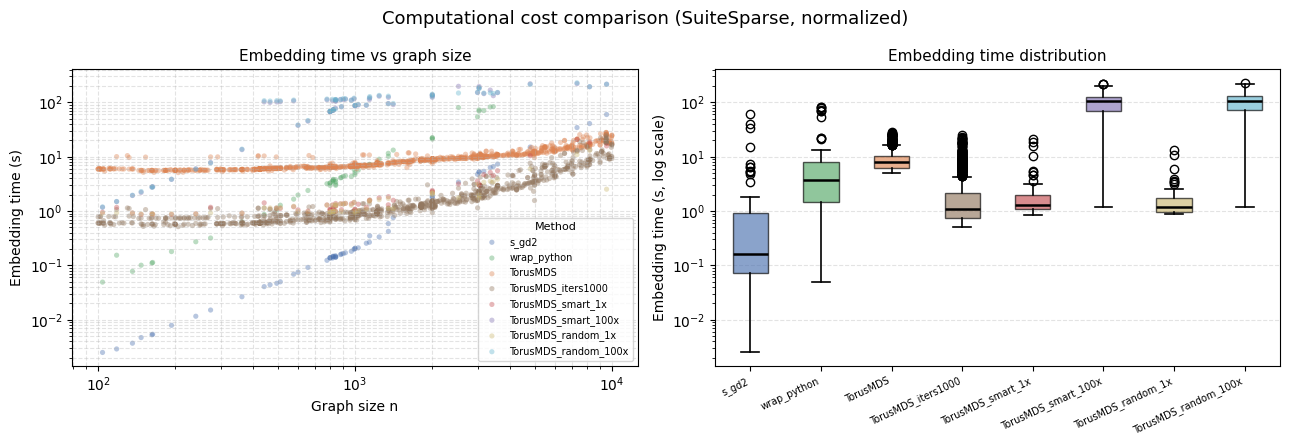

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=14, color=COLORS[m],
               alpha=0.4, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=7, title_fontsize=8)
ax.grid(linestyle='--', alpha=0.35, which='both')

ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=7, rotation=25, ha='right')
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison (SuiteSparse, normalized)', fontsize=13)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [5]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reindex(METHODS).round(4)
summary

,stress_mean,stress_median,stress_std,pointwise_stress_mean,pointwise_stress_median,pointwise_stress_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,
s_gd2,0.1647,0.1314,0.1094,0.2047,0.1919,0.1032,3.4432,0.1604,10.2751
wrap_python,0.2488,0.2632,0.1109,0.2523,0.2296,0.1124,13.4676,3.7955,23.8926
TorusMDS,0.2629,0.2725,0.1201,0.4208,0.3210,0.8932,9.1239,8.0860,4.0324
TorusMDS_iters1000,0.3338,0.3274,0.1112,0.6962,0.3674,1.3775,2.3891,1.0962,3.4027
TorusMDS_smart_1x,0.2201,0.2089,0.1306,0.2687,0.2669,0.1213,2.6500,1.2968,3.9799
TorusMDS_smart_100x,0.2057,0.1720,0.1393,0.2532,0.2210,0.1626,98.9034,104.0695,58.6070
TorusMDS_random_1x,0.1913,0.1649,0.1050,0.2371,0.2251,0.1013,1.8721,1.1942,2.1242
TorusMDS_random_100x,0.1891,0.1565,0.1210,0.2371,0.2072,0.1485,99.6324,107.9952,57.6102


## Percent change vs s_gd2 baseline

For each method, percent change is computed per matched matrix against `s_gd2`
(`100 * (method - s_gd2) / s_gd2`), then averaged over the matched matrices -- pairing on
`matrix_id` controls for per-matrix difficulty, unlike comparing independent means. `s_gd2`
only has 60 matrices (vs. `TorusMDS`'s 1040), so `n_matched` caps every column at 60 or fewer;
`wrap_python` and `TorusMDS_iters1000` may be smaller still. For `stress`/`pointwise_stress`,
negative values mean lower (better) stress than `s_gd2`; for `t_embed`, negative values mean
faster embedding.

In [7]:
def paired_pct_change(df, methods, baseline, id_col, metrics):
    """Per-instance percent change vs `baseline`, matched on `id_col`, then aggregated.

    Pairing on the same graph/matrix (rather than comparing independent means)
    controls for per-instance difficulty, which otherwise dominates the variance.
    """
    base = df[df['method'] == baseline].set_index(id_col)
    rows = {}
    for m in methods:
        if m == baseline:
            continue
        other = df[df['method'] == m].set_index(id_col)
        common = base.index.intersection(other.index)
        pct = {'n_matched': len(common)}
        for metric in metrics:
            vals = 100 * (other.loc[common, metric] - base.loc[common, metric]) / base.loc[common, metric]
            pct[f'{metric}_mean_pct'] = vals.mean()
            pct[f'{metric}_median_pct'] = vals.median()
        rows[m] = pct
    return pd.DataFrame(rows).T

pct_change = paired_pct_change(df, METHODS, 's_gd2', 'matrix_id', METRICS + ['t_embed'])
pct_change.round(2)

,n_matched,stress_mean_pct,stress_median_pct,pointwise_stress_mean_pct,pointwise_stress_median_pct,t_embed_mean_pct,t_embed_median_pct
wrap_python,55.0,80.689737,49.359491,30.047783,12.849340,2158.602567,2250.143472
TorusMDS,60.0,60.522682,8.640509,52.404026,3.464180,24573.592337,3954.993251
TorusMDS_iters1000,60.0,204.099592,79.451366,233.630928,65.391526,2624.048157,402.370956
TorusMDS_smart_1x,60.0,59.326172,16.534441,49.798819,15.149188,3562.459139,644.939160
TorusMDS_smart_100x,60.0,43.416105,3.717933,35.648624,5.142620,52687.470175,48834.015744
TorusMDS_random_1x,60.0,37.060671,4.080472,26.817752,6.181263,3347.374464,589.568284
TorusMDS_random_100x,60.0,31.744579,1.597524,26.875544,3.081006,54155.960873,49432.681977


### Percent-change distributions (strip plot)

Same paired comparison as above, shown as the full per-matrix distribution rather than a single
summary number. Each dot is one matched matrix; the black tick marks the median. Methods with
fewer than 5 matched instances vs. `s_gd2` are omitted.

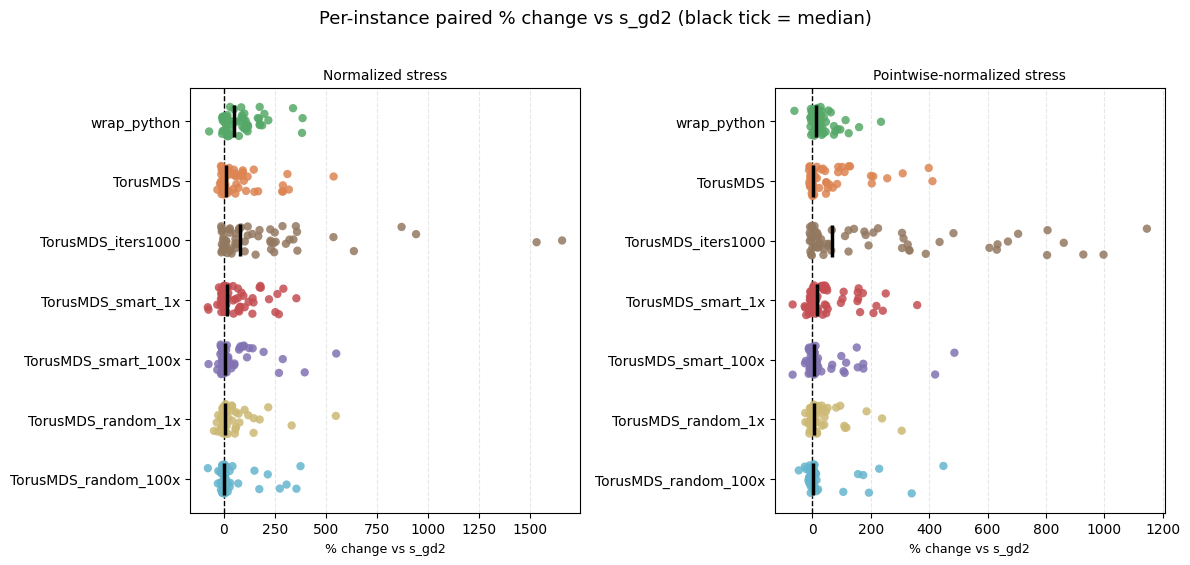

In [2]:
def paired_pct_change_long(df, methods, baseline, id_col, metrics, extra_cols=None):
    """Long-form per-instance percent change vs `baseline`, matched on `id_col`."""
    extra_cols = extra_cols or []
    base = df[df['method'] == baseline].set_index(id_col)
    frames = []
    for m in methods:
        if m == baseline:
            continue
        other = df[df['method'] == m].set_index(id_col)
        common = base.index.intersection(other.index)
        if len(common) == 0:
            continue
        for metric in metrics:
            pct = 100 * (other.loc[common, metric] - base.loc[common, metric]) / base.loc[common, metric]
            frame = pd.DataFrame({'method': m, 'metric': metric, id_col: common, 'pct_change': pct.values})
            for col in extra_cols:
                frame[col] = base.loc[common, col].values
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def bootstrap_median_ci(vals, n_boot=2000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    vals = np.asarray(vals, dtype=float)
    boots = rng.choice(vals, size=(n_boot, len(vals)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return np.median(vals), lo, hi


MIN_N_FOR_DIST = 5  # below this a histogram/CI isn't meaningful (e.g. wrap_python's capped sample)
_methods_no_base = [m for m in METHODS if m != 's_gd2']
_n_matched = {
    m: len(set(df[df['method'] == m]['matrix_id']) & set(df[df['method'] == 's_gd2']['matrix_id']))
    for m in _methods_no_base
}
plot_methods = [m for m in _methods_no_base if _n_matched[m] >= MIN_N_FOR_DIST]
_skipped = [m for m in _methods_no_base if m not in plot_methods]
if _skipped:
    print(f"Skipping {_skipped} (fewer than {MIN_N_FOR_DIST} matched instances vs s_gd2)")

pct_long = paired_pct_change_long(df, METHODS, 's_gd2', 'matrix_id', METRICS)

import seaborn as sns

groups = [None]
palette = {m: COLORS[m] for m in plot_methods}
fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(6 * len(METRICS), 0.6 * len(plot_methods) + 1.3 * 1),
    squeeze=False,
)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = pct_long[pct_long['metric'] == metric]
        
        sub = sub[sub['method'].isin(plot_methods)]
        sns.stripplot(
            data=sub, x='pct_change', y='method', order=plot_methods, hue='method',
            hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
            ax=ax, legend=False,
        )
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['pct_change'].dropna().values
            if len(vals) == 0:
                continue
            ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5,
                       color='black', zorder=5)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(LABELS[metric], fontsize=10)
        ax.set_xlabel('% change vs s_gd2', fontsize=9)
        ax.set_ylabel('')
        ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance paired % change vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_pct_change_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Percent-change: median with 95% bootstrap CI

Bootstrap (2000 resamples) 95% CI on the median paired percent change. This is the number to
quote in the paper if you want a single point estimate with uncertainty rather than reporting the
mean, which the earlier table shows is skewed by a few outlier matrices.

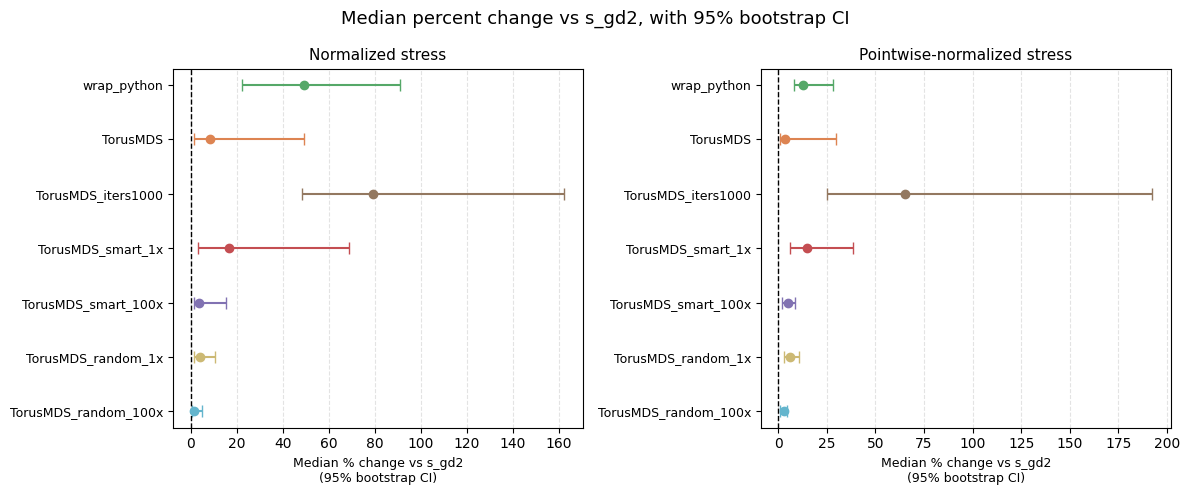

In [3]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 0.5 * len(plot_methods) + 1.5 * 1), squeeze=False)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = pct_long[pct_long['metric'] == metric]
        
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['pct_change'].dropna().values
            if len(vals) == 0:
                continue
            med, lo, hi = bootstrap_median_ci(vals)
            ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(range(len(plot_methods)))
        ax.set_yticklabels(plot_methods, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Median % change vs s_gd2\n(95% bootstrap CI)', fontsize=9)
        ax.set_title(LABELS[metric], fontsize=11)
        ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle('Median percent change vs s_gd2, with 95% bootstrap CI', fontsize=13)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_pct_change_ci.png', dpi=150, bbox_inches='tight')
plt.show()

### Symmetric percent change (SPC) distributions (strip plot)

SPC = (method - s_gd2) / max(|method|, |s_gd2|), scaled to a percentage -- unlike the plain
percent change above (which ran past +1500% for a few matrices), it is bounded to [-100, 100].
Same per-instance layout as the percent-change strip plot above.

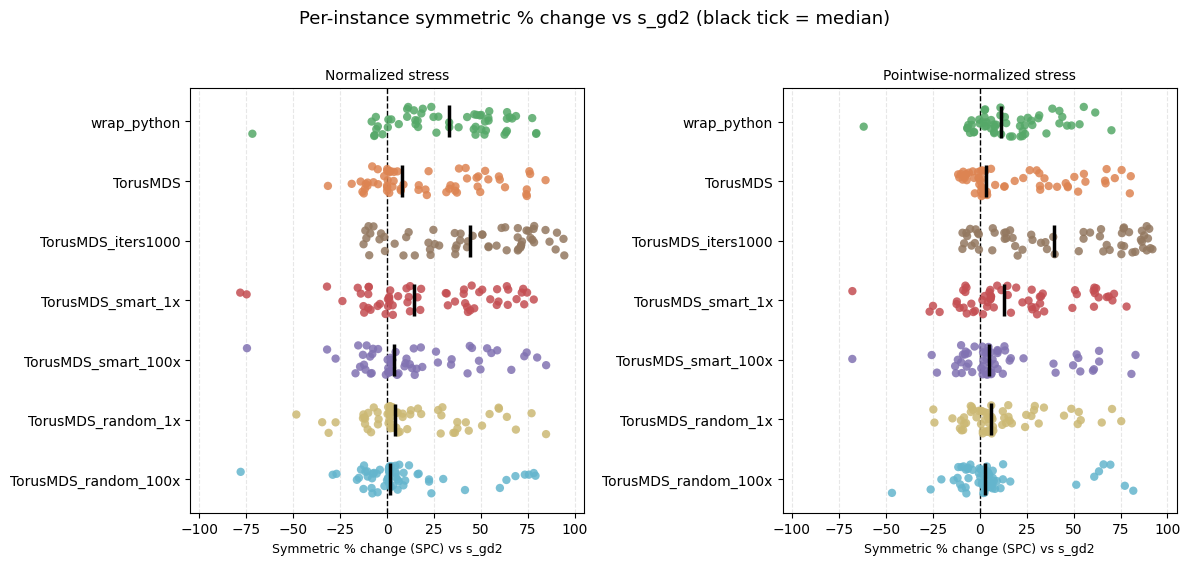

In [4]:
def paired_spc_long(df, methods, baseline, id_col, metrics, extra_cols=None):
    """Per-instance symmetric percent change vs `baseline`, matched on `id_col`.

    SPC = (A - B) / max(|A|, |B|), scaled to a percentage. Bounded to [-100, 100]
    (our metrics are all non-negative), unlike plain percent change, which blows up
    whenever the baseline is small.
    """
    extra_cols = extra_cols or []
    base = df[df['method'] == baseline].set_index(id_col)
    frames = []
    for m in methods:
        if m == baseline:
            continue
        other = df[df['method'] == m].set_index(id_col)
        common = base.index.intersection(other.index)
        if len(common) == 0:
            continue
        for metric in metrics:
            a = other.loc[common, metric]
            b = base.loc[common, metric]
            denom = np.maximum(a.abs(), b.abs())
            spc = 100 * (a - b) / denom
            frame = pd.DataFrame({'method': m, 'metric': metric, id_col: common, 'spc': spc.values})
            for col in extra_cols:
                frame[col] = base.loc[common, col].values
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


spc_long = paired_spc_long(df, METHODS, 's_gd2', 'matrix_id', METRICS)

fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(6 * len(METRICS), 0.6 * len(plot_methods) + 1.3 * 1),
    squeeze=False,
)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = spc_long[spc_long['metric'] == metric]
        
        sub = sub[sub['method'].isin(plot_methods)]
        sns.stripplot(
            data=sub, x='spc', y='method', order=plot_methods, hue='method',
            hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
            ax=ax, legend=False,
        )
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['spc'].dropna().values
            if len(vals) == 0:
                continue
            ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5,
                       color='black', zorder=5)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xlim(-105, 105)
        ax.set_title(LABELS[metric], fontsize=10)
        ax.set_xlabel('Symmetric % change (SPC) vs s_gd2', fontsize=9)
        ax.set_ylabel('')
        ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance symmetric % change vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_spc_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### SPC: median with 95% bootstrap CI

Because SPC is bounded, its distribution is far less outlier-driven than the plain percent
change's -- the mean and median are much closer together here (compare to the earlier table).
Median is still shown for direct visual consistency with the percent-change CI plot above.

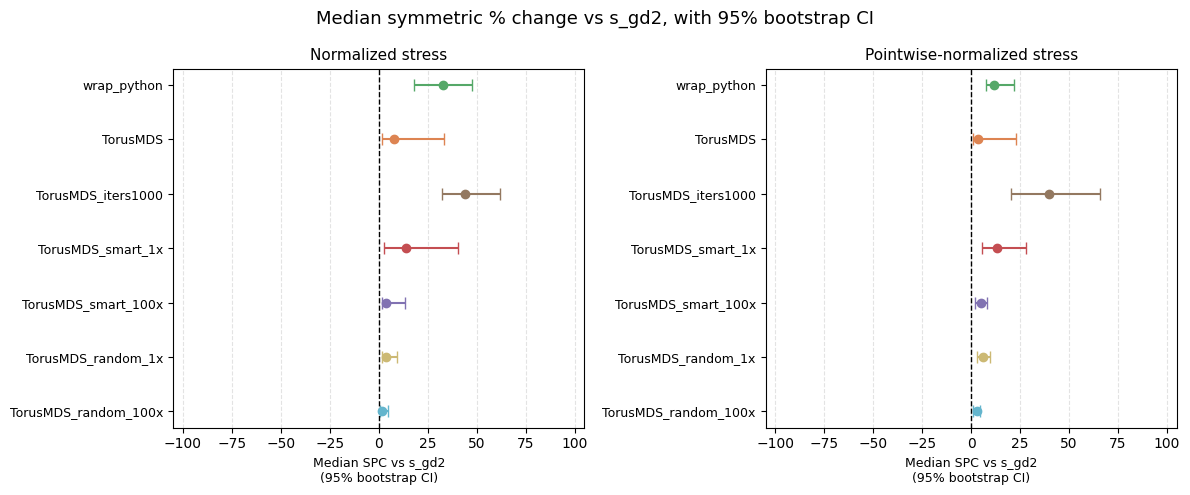

In [5]:
fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(6 * len(METRICS), 0.5 * len(plot_methods) + 1.5 * 1),
    squeeze=False,
)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = spc_long[spc_long['metric'] == metric]
        
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['spc'].dropna().values
            if len(vals) == 0:
                continue
            med, lo, hi = bootstrap_median_ci(vals)
            ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(range(len(plot_methods)))
        ax.set_yticklabels(plot_methods, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlim(-105, 105)
        ax.set_xlabel('Median SPC vs s_gd2\n(95% bootstrap CI)', fontsize=9)
        ax.set_title(LABELS[metric], fontsize=11)
        ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle(
    'Median symmetric % change vs s_gd2, with 95% bootstrap CI',
    fontsize=13,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_spc_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## Runtime: percent change vs s_gd2

The same paired-instance approach as the accuracy metrics above, applied to embedding time.

### Embedding-time percent change (strip plot)

Runtime ratios span orders of magnitude (the `100x` batch-size variants are, unsurprisingly,
~100x slower), so the x-axis uses a symmetric log scale (linear within ±10%, log beyond).
Same per-instance layout as the accuracy strip plots above.

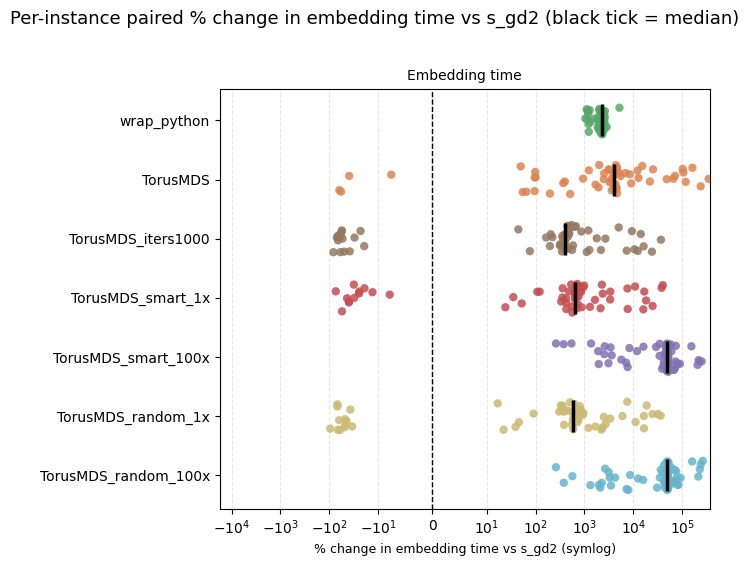

In [6]:
RUNTIME_METRICS = ['t_embed']
pct_long_time = paired_pct_change_long(df, METHODS, 's_gd2', 'matrix_id', RUNTIME_METRICS)

fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.6 * len(plot_methods) + 1.3 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = pct_long_time[pct_long_time['metric'] == 't_embed']
    
    sub = sub[sub['method'].isin(plot_methods)]
    sns.stripplot(
        data=sub, x='pct_change', y='method', order=plot_methods, hue='method',
        hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
        ax=ax, legend=False,
    )
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['pct_change'].dropna().values
        if len(vals) == 0:
            continue
        ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5, color='black', zorder=5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('symlog', linthresh=10)
    ax.set_title('Embedding time', fontsize=10)
    ax.set_xlabel('% change in embedding time vs s_gd2 (symlog)', fontsize=9)
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance paired % change in embedding time vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_time_pct_change_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Embedding-time percent change: median with 95% bootstrap CI

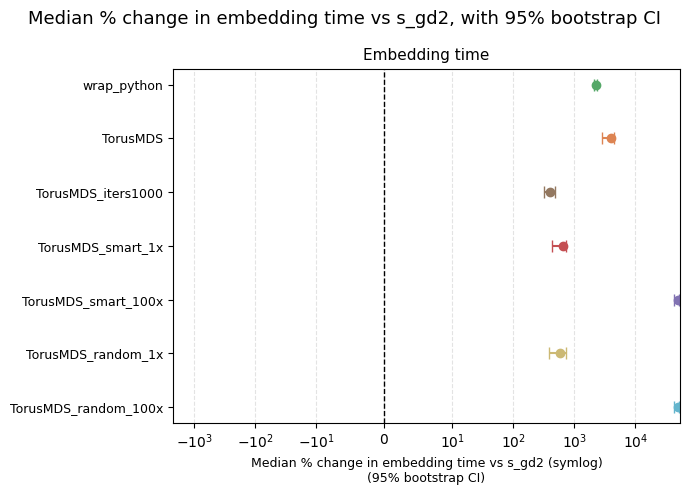

In [7]:
fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.5 * len(plot_methods) + 1.5 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = pct_long_time[pct_long_time['metric'] == 't_embed']
    
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['pct_change'].dropna().values
        if len(vals) == 0:
            continue
        med, lo, hi = bootstrap_median_ci(vals)
        ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('symlog', linthresh=10)
    ax.set_yticks(range(len(plot_methods)))
    ax.set_yticklabels(plot_methods, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Median % change in embedding time vs s_gd2 (symlog)\n(95% bootstrap CI)', fontsize=9)
    ax.set_title('Embedding time', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle(
    'Median % change in embedding time vs s_gd2, with 95% bootstrap CI',
    fontsize=13,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_time_pct_change_ci.png', dpi=150, bbox_inches='tight')
plt.show()

### Embedding-time symmetric percent change (SPC) (strip plot)

Same SPC definition as for the accuracy metrics, bounded to [-100, 100] -- useful here since
runtime's plain percent change is heavy-tailed enough to need a log axis above.

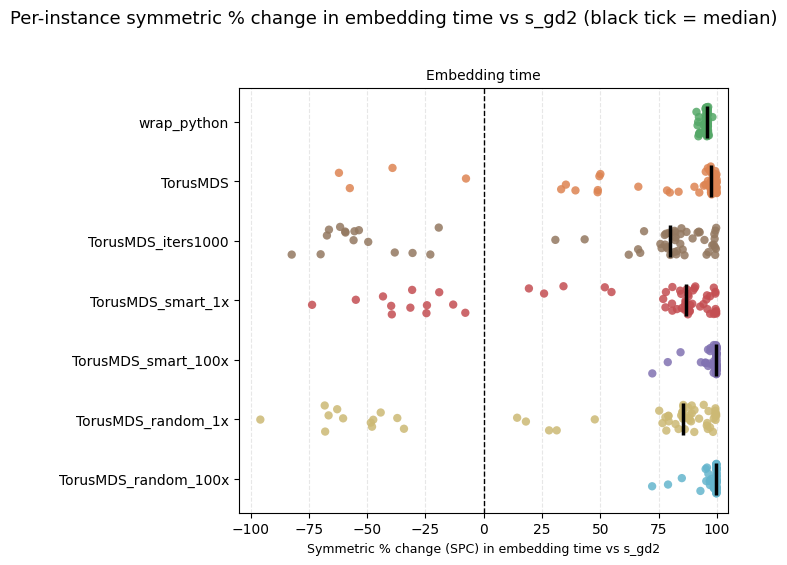

In [8]:
spc_long_time = paired_spc_long(df, METHODS, 's_gd2', 'matrix_id', RUNTIME_METRICS)

fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.6 * len(plot_methods) + 1.3 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = spc_long_time[spc_long_time['metric'] == 't_embed']
    
    sub = sub[sub['method'].isin(plot_methods)]
    sns.stripplot(
        data=sub, x='spc', y='method', order=plot_methods, hue='method',
        hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
        ax=ax, legend=False,
    )
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['spc'].dropna().values
        if len(vals) == 0:
            continue
        ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5, color='black', zorder=5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(-105, 105)
    ax.set_title('Embedding time', fontsize=10)
    ax.set_xlabel('Symmetric % change (SPC) in embedding time vs s_gd2', fontsize=9)
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance symmetric % change in embedding time vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_time_spc_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Embedding-time SPC: median with 95% bootstrap CI

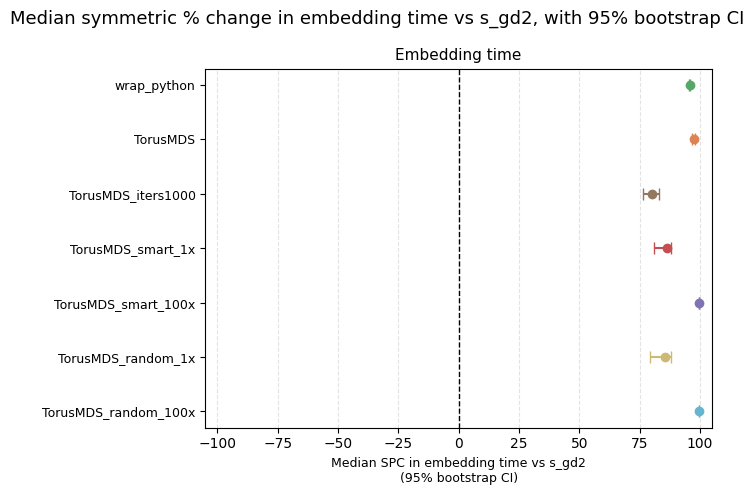

In [9]:
fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.5 * len(plot_methods) + 1.5 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = spc_long_time[spc_long_time['metric'] == 't_embed']
    
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['spc'].dropna().values
        if len(vals) == 0:
            continue
        med, lo, hi = bootstrap_median_ci(vals)
        ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(-105, 105)
    ax.set_yticks(range(len(plot_methods)))
    ax.set_yticklabels(plot_methods, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Median SPC in embedding time vs s_gd2\n(95% bootstrap CI)', fontsize=9)
    ax.set_title('Embedding time', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle(
    'Median symmetric % change in embedding time vs s_gd2, with 95% bootstrap CI',
    fontsize=13,
)
fig.tight_layout()
plt.savefig('../results/suitesparse_normalized_time_spc_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## Performance by SuiteSparse group

Top 10 groups by graph count -- too many groups total to plot cleanly, so this is a table rather than a chart.

In [6]:
top_groups = df.drop_duplicates('matrix_id')['group'].value_counts().head(10).index
by_group = (
    df[df['group'].isin(top_groups)]
    .groupby(['group', 'method'])[METRICS]
    .mean()
    .round(4)
)
by_group

stress  pointwise_stress
group        method                                        
Bai          TorusMDS              0.2371            0.6720
             TorusMDS_iters1000    0.3708            1.6258
             TorusMDS_random_100x  0.1160            0.1685
             TorusMDS_random_1x    0.1602            0.2157
             TorusMDS_smart_100x   0.1304            0.1912
             TorusMDS_smart_1x     0.1653            0.2334
             s_gd2                 0.1282            0.1776
             wrap_python           0.2074            0.2168
DRIVCAV      TorusMDS              0.1438            0.1859
             TorusMDS_iters1000    0.1997            0.2652
             TorusMDS_random_100x  0.1064            0.1382
             TorusMDS_random_1x    0.1104            0.1385
             TorusMDS_smart_100x   0.1886            0.2882
             TorusMDS_smart_1x     0.2290            0.3257
             s_gd2                 0.1038            0.1318
             wrap_python           0.2818            0.2290
FIDAP        TorusMDS              0.1287            0.1892
             TorusMDS_iters1000    0.2746            0.4438
             TorusMDS_random_100x  0.1250            0.1847
             TorusMDS_random_1x    0.1023            0.1751
             TorusMDS_smart_100x   0.0874            0.1497
             TorusMDS_smart_1x     0.1246            0.1915
             s_gd2                 0.0793            0.1447
             wrap_python           0.1749            0.1700
Gset         TorusMDS              0.3498            0.4007
             TorusMDS_iters1000    0.3902            0.5704
             TorusMDS_random_100x  0.2895            0.3124
             TorusMDS_random_1x    0.2865            0.3399
             TorusMDS_smart_100x   0.3830            0.3817
             TorusMDS_smart_1x     0.3759            0.3811
             s_gd2                 0.3082            0.3342
             wrap_python           0.3372            0.3502
HB           TorusMDS              0.2036            0.2558
             TorusMDS_iters1000    0.2840            0.4150
             TorusMDS_random_100x  0.1927            0.2330
             TorusMDS_random_1x    0.1825            0.2237
             TorusMDS_smart_100x   0.1811            0.2188
             TorusMDS_smart_1x     0.1959            0.2473
             s_gd2                 0.1580            0.1958
             wrap_python           0.2313            0.2351
ML_Graph     TorusMDS              0.2639            0.3373
             TorusMDS_iters1000    0.3010            0.5025
Pajek        TorusMDS              0.3048            0.3286
             TorusMDS_iters1000    0.3281            0.3604
Sandia       TorusMDS              0.2449            0.2865
             TorusMDS_iters1000    0.3234            0.5357
Schenk_IBMNA TorusMDS              0.3423            0.3572
             TorusMDS_iters1000    0.3679            0.3892
VDOL         TorusMDS              0.3082            0.3274
             TorusMDS_iters1000    0.3254            0.3463